# CS5811 — Phase 1: Data Loading & Inspection

**Hypothesis.** Stress level and sleep quality are jointly shaped by mobile device usage, sleep behaviour, and lifestyle factors — but the strength and shape of those relationships differ across feature families, and characterising them reliably requires both classical machine learning and high-performance computational methods.

**Research question.** To what extent can mobile device usage patterns, sleep behaviour, and lifestyle factors predict stress levels and sleep quality — and which ML/HPC approaches provide the most accurate and scalable predictions?

**Phase 1 scope:** 1) load and inspect data  2) summary statistics  3) histograms of raw features  4) missing value check  5) export inspected data for Phase 2.

## Setup

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

os.makedirs('Output',   exist_ok=True)
os.makedirs('figures', exist_ok=True)

In [24]:
df = pd.read_csv('sleep_mobile_stress_dataset_15000.csv')
print(df.shape)
df.head()

(15000, 13)


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


---
# Phase 1 — Data Loading & Inspection

### 1 · Inspect data structure

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  str    
 3   occupation                        15000 non-null  str    
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  mental_fatigue_

15,000 rows, 13 columns. Two categorical (`gender`, `occupation`), the rest numeric. No null entries reported by `info()` — confirmed below.

### 2 · Summary statistics

In [26]:
df.describe().round(2)

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,7500.50,38.49,5.50,59.71,6.51,6.25,6.98,2.00,59.16,160.89,6.87
std,4330.27,12.01,2.60,34.64,1.45,1.71,2.75,1.41,34.53,80.86,2.73
min,1.00,18.00,1.00,0.00,4.00,1.00,1.00,0.00,0.00,20.00,1.00
25%,3750.75,28.00,3.26,29.00,5.26,5.00,4.75,1.00,29.00,92.00,4.70
50%,7500.50,38.00,5.49,60.00,6.49,6.25,7.38,2.00,59.00,162.00,7.38
75%,11250.25,49.00,7.76,90.00,7.79,7.50,10.00,3.00,89.00,231.00,9.45
max,15000.00,59.00,10.00,119.00,9.00,10.00,10.00,4.00,119.00,299.00,10.00


Stress and sleep quality are both on a 1–10 scale. Screen time, phone use, caffeine, activity, and notifications span wide ranges — `StandardScaler` will be needed in Phase 3 for any model that's sensitive to feature magnitude.

In [27]:
df.describe(include=['object'])

C:\Users\gaura\AppData\Local\Temp\ipykernel_62364\3011300674.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,gender,occupation
count,15000,15000
unique,3,8
top,Male,Manager
freq,7234,1962


Gender has 3 distinct values, occupation has 8 — both manageable for one-hot encoding in Phase 3.

### 3 · Histograms of raw features

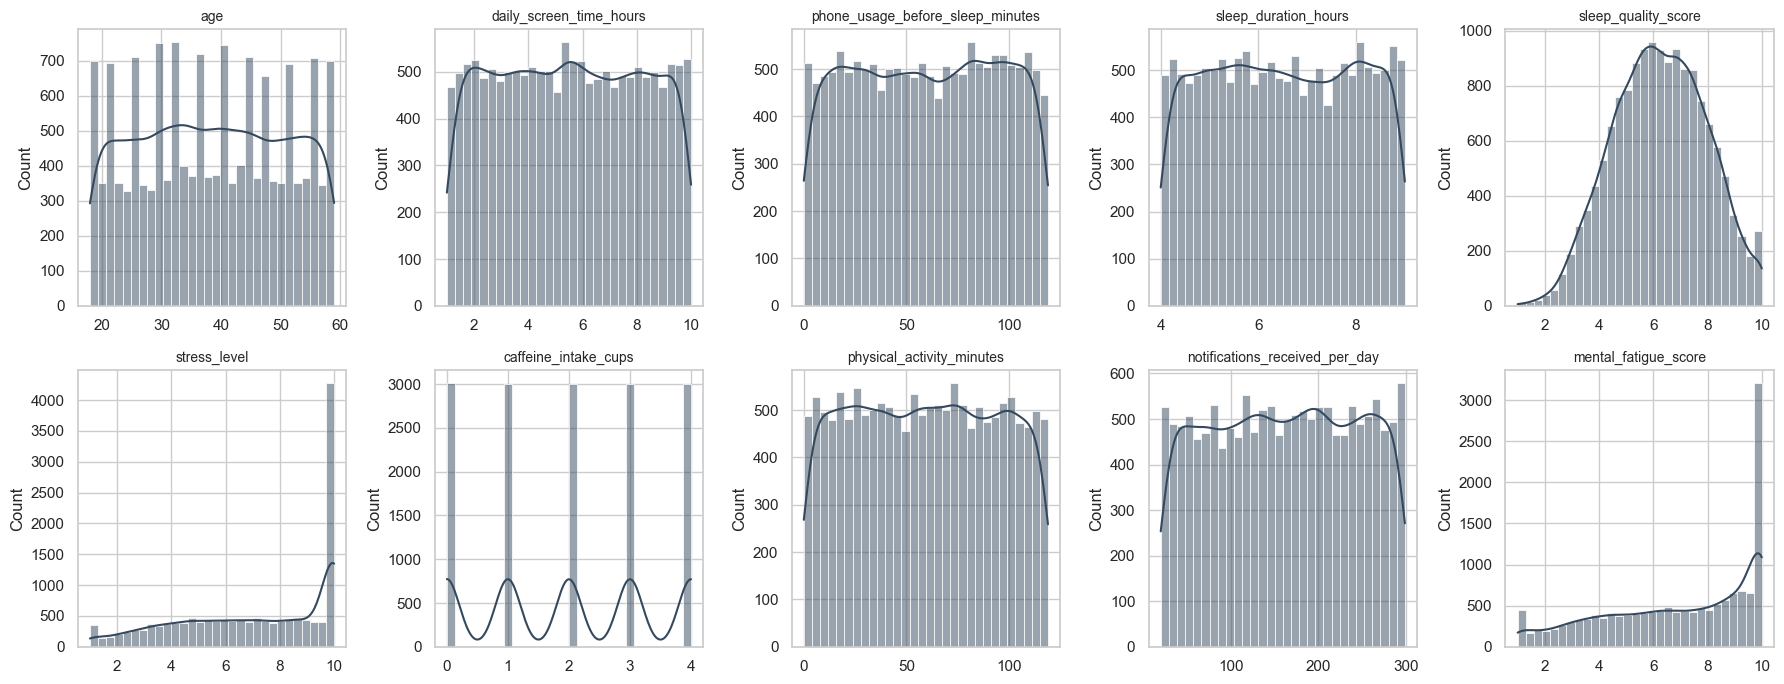

In [28]:
numeric_cols = ['age', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
                'sleep_duration_hours', 'sleep_quality_score', 'stress_level',
                'caffeine_intake_cups', 'physical_activity_minutes',
                'notifications_received_per_day', 'mental_fatigue_score']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='#34495e')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('figures/phase1_histograms.png', dpi=120, bbox_inches='tight')
plt.show()

Stress skews right (more high-stress rows), sleep quality skews left — the two targets look like mirror images, which is the first hint they share underlying structure. Most other features look approximately symmetric.

### 4 · Categorical value counts

In [29]:
df['gender'].value_counts()

gender
Male      7234
Female    7181
Other      585
Name: count, dtype: int64

In [30]:
df['occupation'].value_counts()

occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64

All categories have ≥1,800 rows. No rare-category grouping required for encoding.

### 5 · Missing values

In [31]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

Zero missing values across all columns. No imputation needed and no rows dropped.

### 6 · Export inspected data

In [32]:
df = df.drop(columns=['user_id'])

df.to_csv('Output/cleaned_dataset.csv', index=False)
print('Output/cleaned_dataset.csv  →', df.shape)

Output/cleaned_dataset.csv  → (15000, 12)


`user_id` dropped because it is a row identifier, not a predictor. Phase 2 (EDA) imports `raw_inspected.csv`.